In [98]:
import os
import shutil
from datetime import datetime
import json

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d



import h5py
import matplotlib.pyplot as plt
import numpy as np

In [99]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [100]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

# 1. Setup

In [101]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [102]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [14]:
print_tree(data['data'], max_level=4)

coupling_point_1
- disordered
- - ((1, 2), (3, 4))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (4, 5))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (6, 7))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((1, 2), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((2, 3), (4, 5))
- - ((2, 3), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((2, 3), (6, 7))
- - ((2, 3), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (5, 6))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (6, 7))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((3, 4), (7, 8))
- - - population_difference
- - - times
- - - beamsplitter_time_guess
- - ((4, 5), (6, 7

In [103]:
coupling_point = 'coupling_point_2'

In [104]:
correlation_pairs = []

for i in range(1, 6):
    for j in range(i+2, 8):
        correlation_pairs.append(((i,i+1),(j,j+1)))

print(correlation_pairs)
print(len(correlation_pairs))

[((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8))]
15


### 1.1 Load Config

In [107]:
config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)


coupling_point_config = config[coupling_point]


### 1.2 Extract Data

In [108]:
correlation_pair_to_population_difference = {}
correlation_pair_to_population_times = {}

In [109]:
for correlation_pair in correlation_pairs:

    # check if data exists 'disordered' state

    disoreded_in_dict = 'disordered' in data['data'][coupling_point]
    correlation_pair_in_dict = disoreded_in_dict and str(correlation_pair) in data['data'][coupling_point]['disordered']
    data_in_dict = disoreded_in_dict and correlation_pair_in_dict and len(data['data'][coupling_point]['disordered'][str(correlation_pair)]) > 0

    if data_in_dict:
        # use disordered data
        print(f'using disordered state for correlation pair {correlation_pair}')
        correlation_pair_data = data['data'][coupling_point]['disordered'][str(correlation_pair)]
        beamsplitter_time_guess = correlation_pair_data['beamsplitter_time_guess']
    else:
        # use highest data
        print(f'using highest state for correlation pair {correlation_pair}')
        correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]
        beamsplitter_time_guess = correlation_pair_data['beamsplitter_time']


    times = correlation_pair_data['times']
    population_difference = correlation_pair_data['population_difference']

    correlation_pair_to_population_difference[correlation_pair] = population_difference
    correlation_pair_to_population_times[correlation_pair] = times



using highest state for correlation pair ((1, 2), (3, 4))
using highest state for correlation pair ((1, 2), (4, 5))
using highest state for correlation pair ((1, 2), (5, 6))
using highest state for correlation pair ((1, 2), (6, 7))
using highest state for correlation pair ((1, 2), (7, 8))
using highest state for correlation pair ((2, 3), (4, 5))
using highest state for correlation pair ((2, 3), (5, 6))
using highest state for correlation pair ((2, 3), (6, 7))
using highest state for correlation pair ((2, 3), (7, 8))
using highest state for correlation pair ((3, 4), (5, 6))
using highest state for correlation pair ((3, 4), (6, 7))
using highest state for correlation pair ((3, 4), (7, 8))
using highest state for correlation pair ((4, 5), (6, 7))
using highest state for correlation pair ((4, 5), (7, 8))
using highest state for correlation pair ((5, 6), (7, 8))


### 1.3 Plot Population Differences

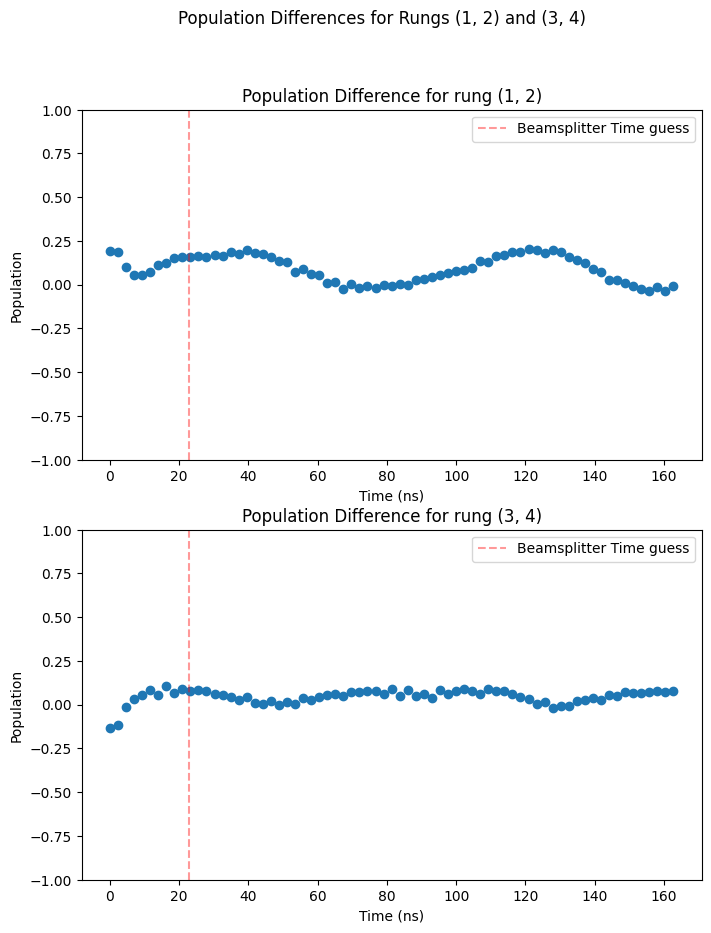

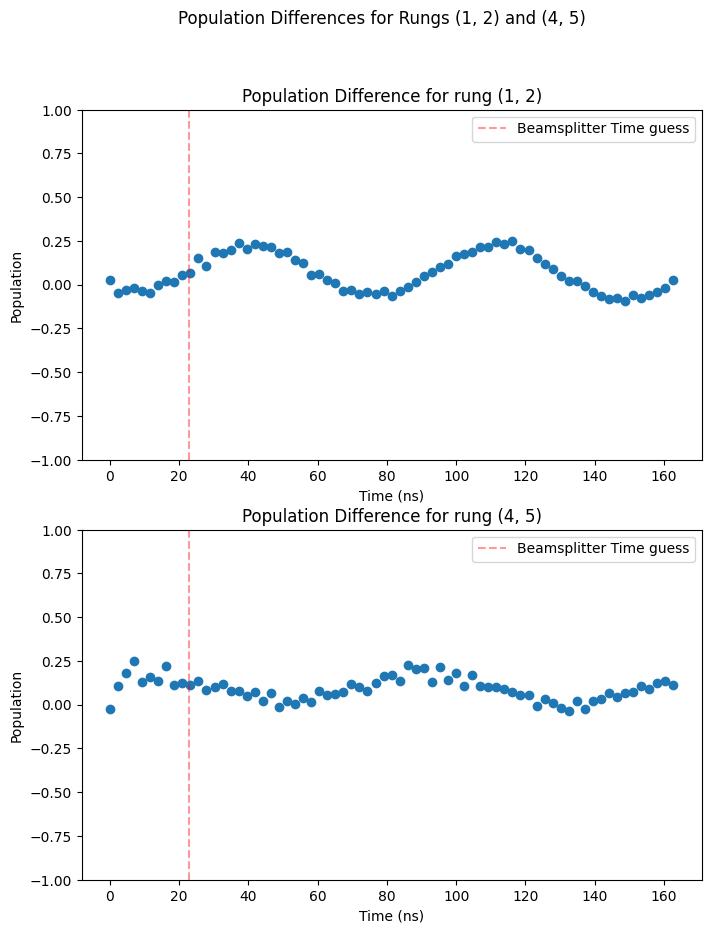

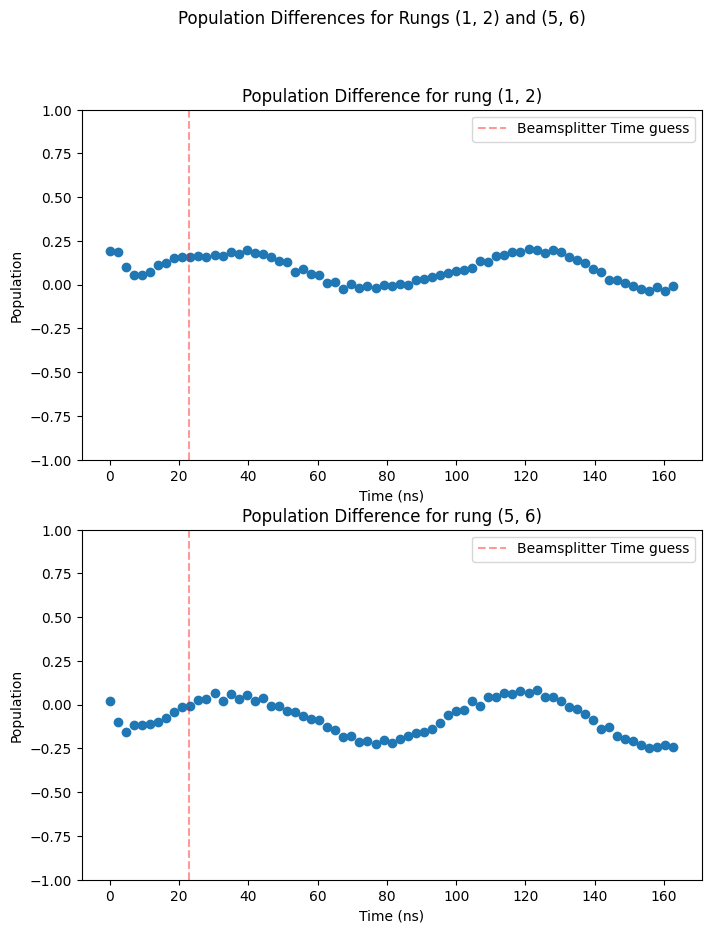

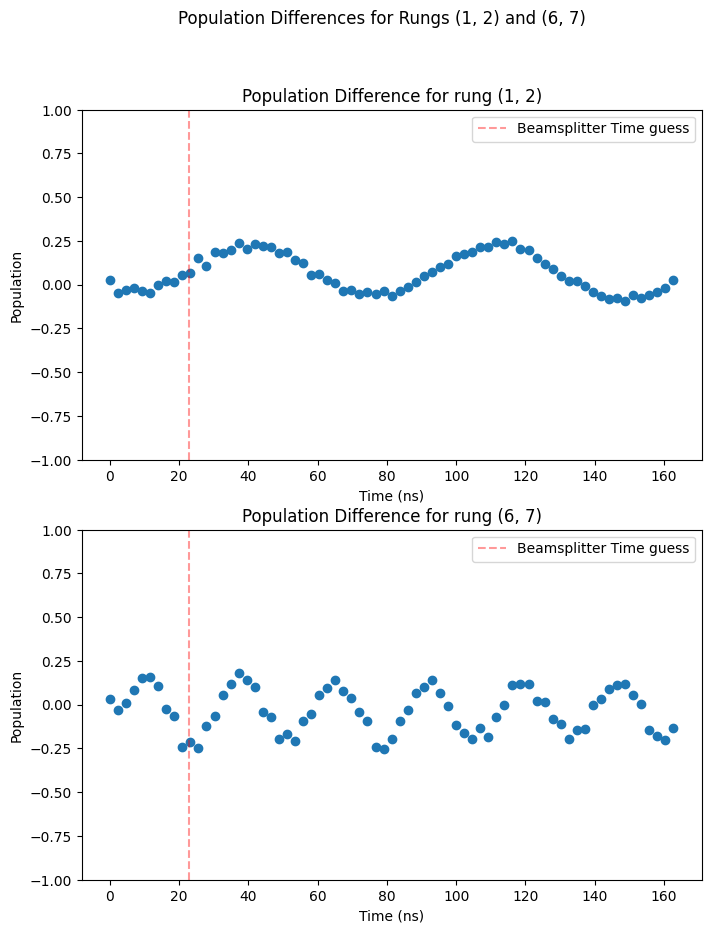

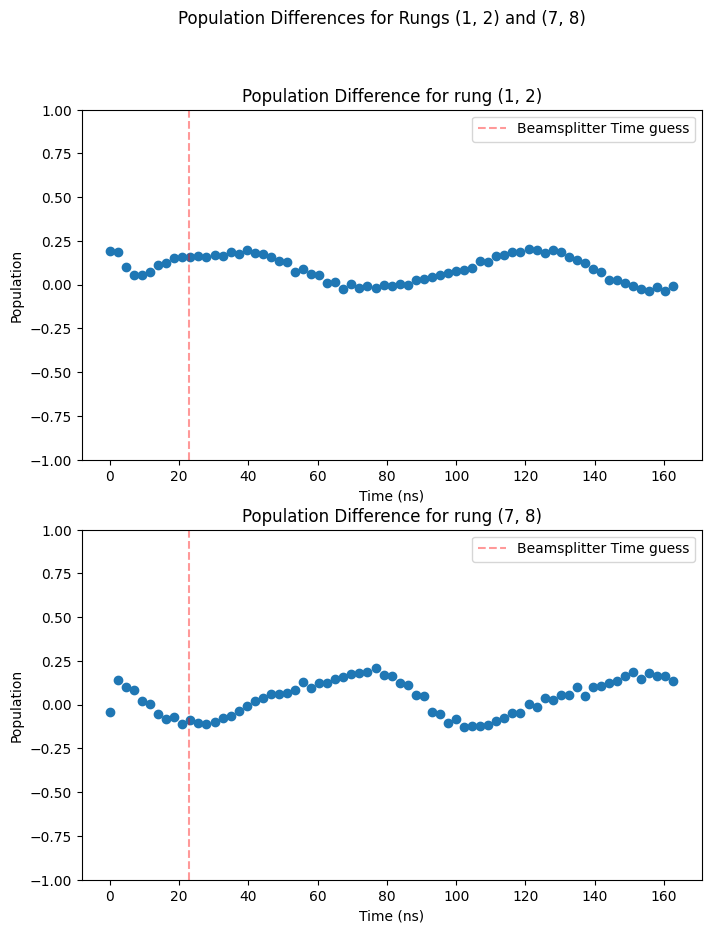

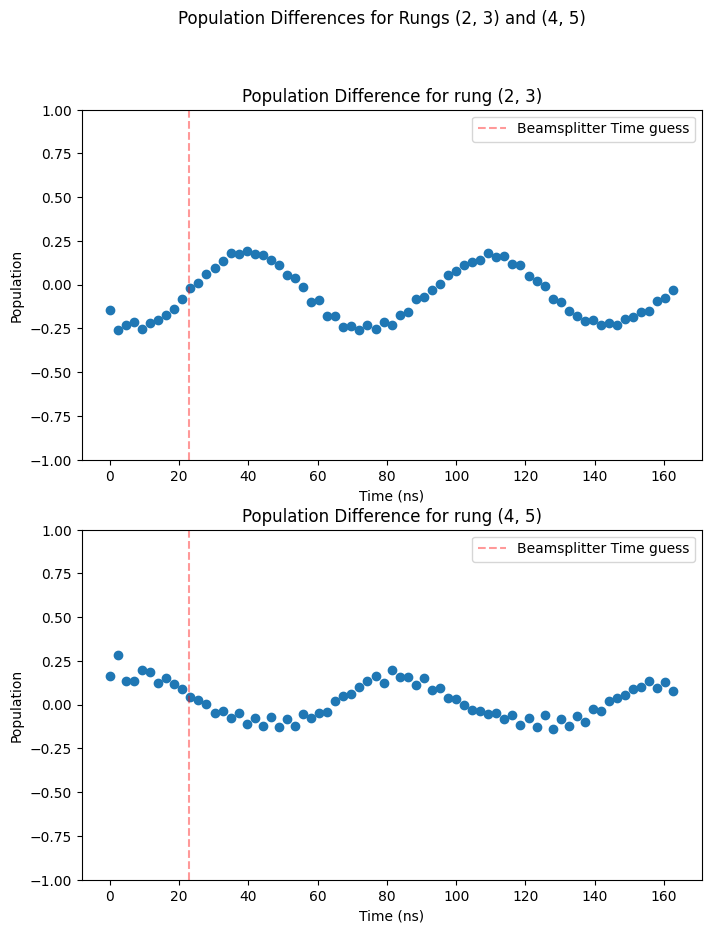

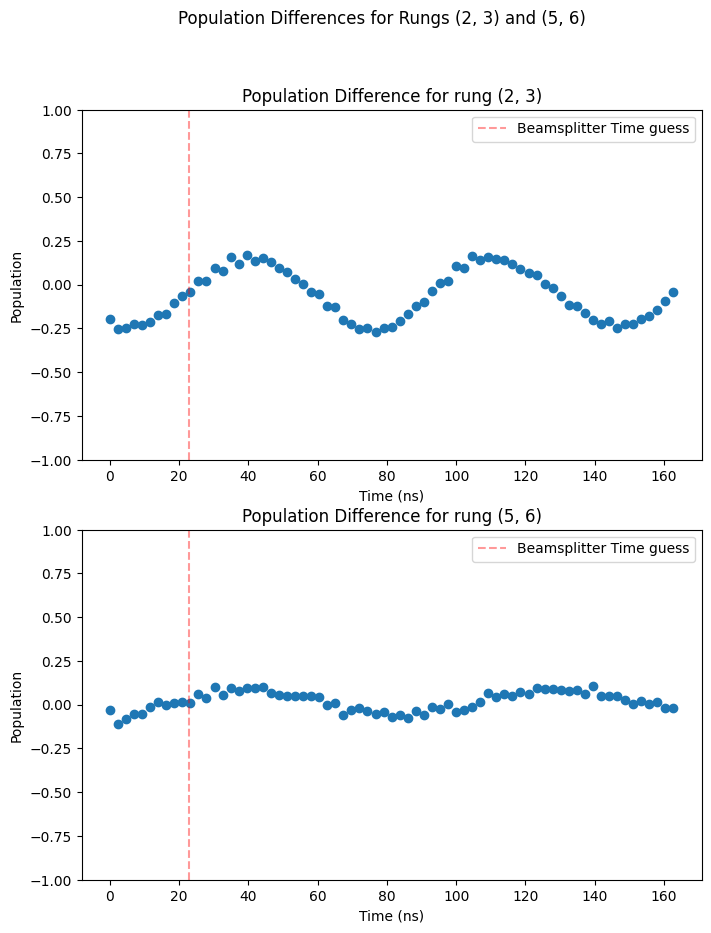

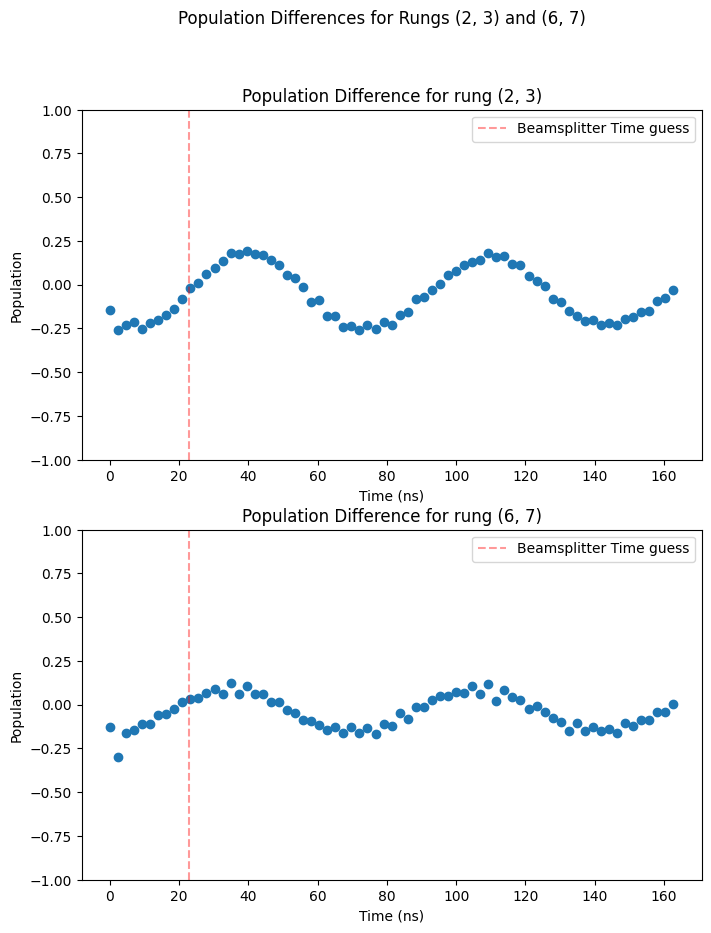

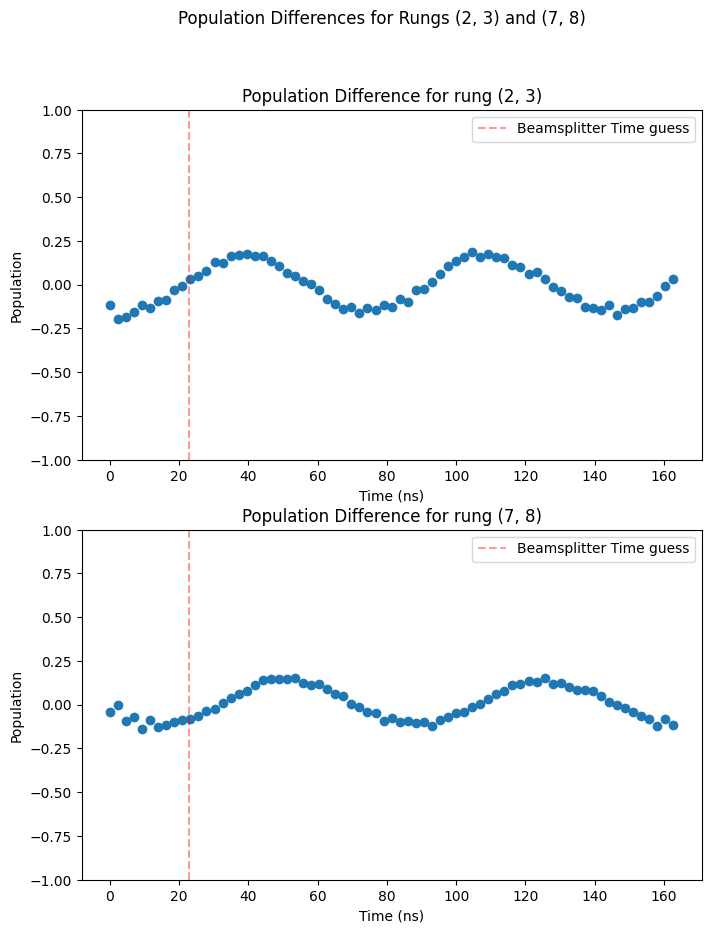

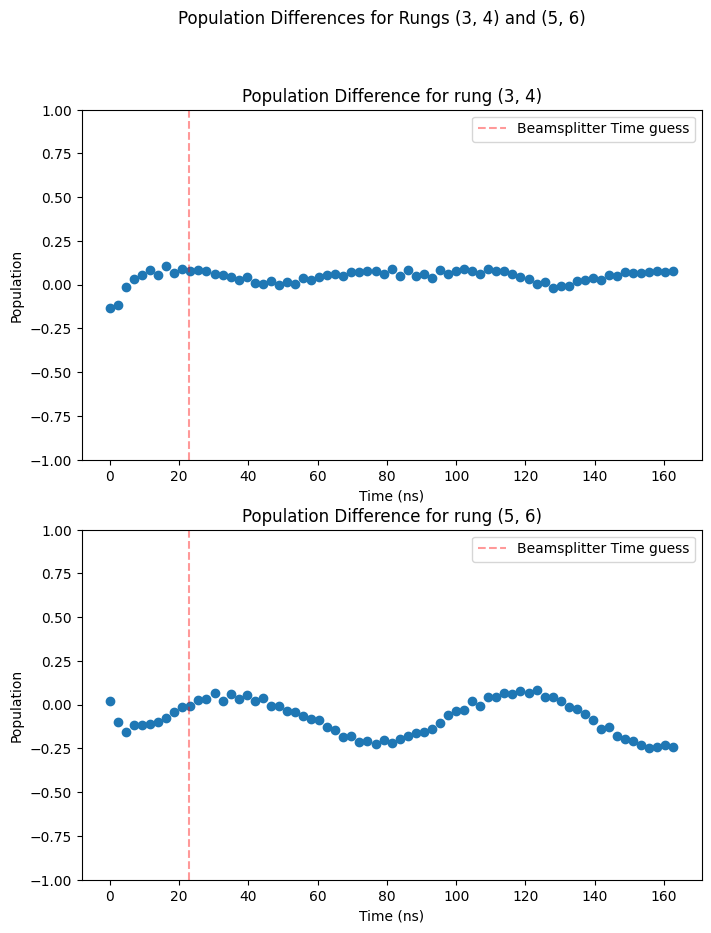

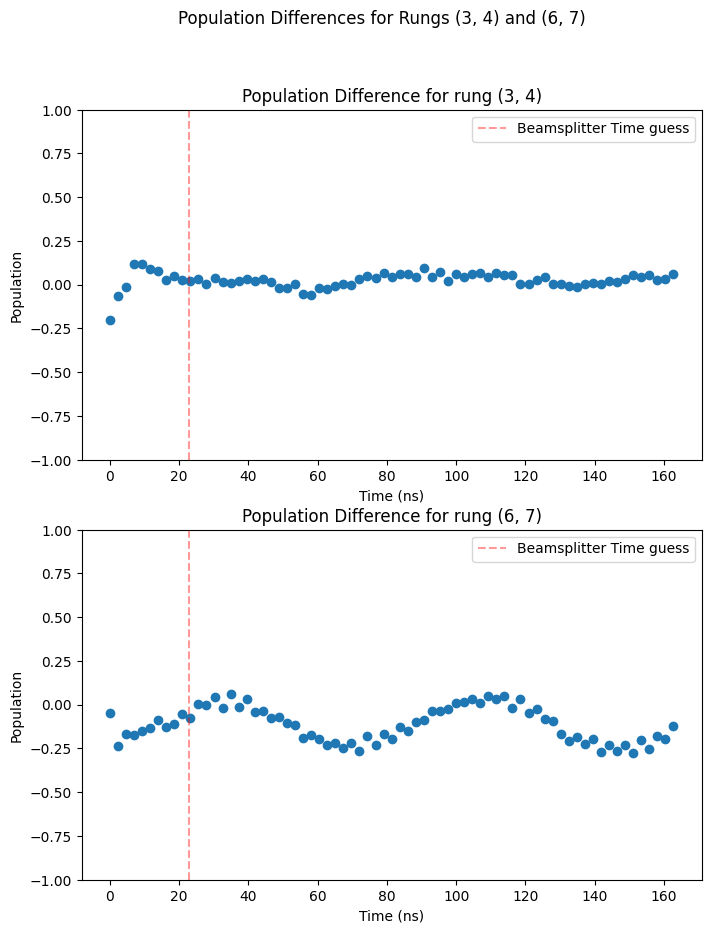

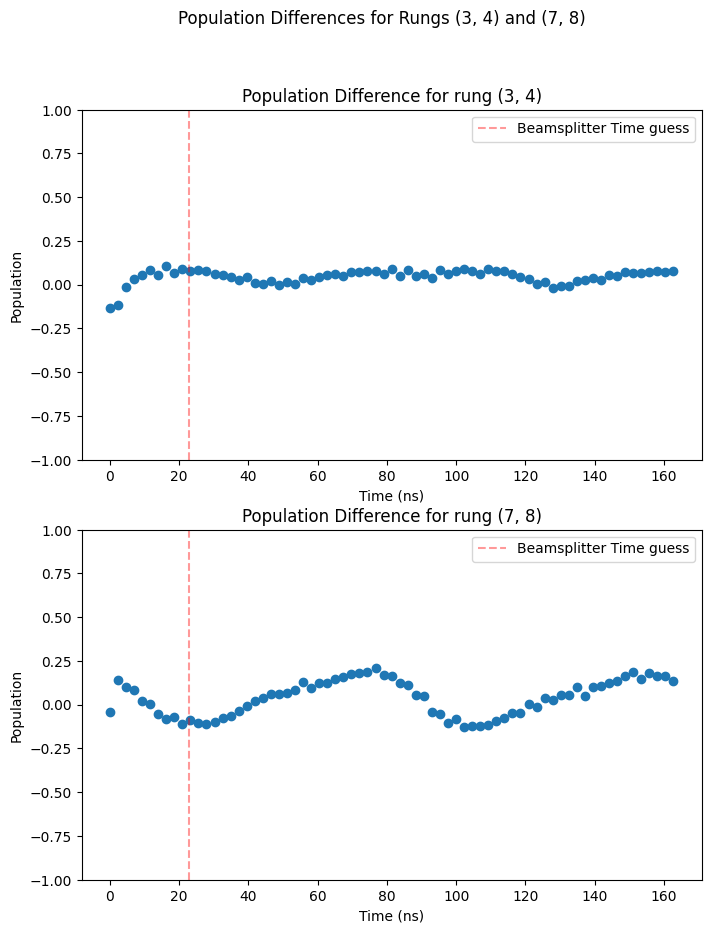

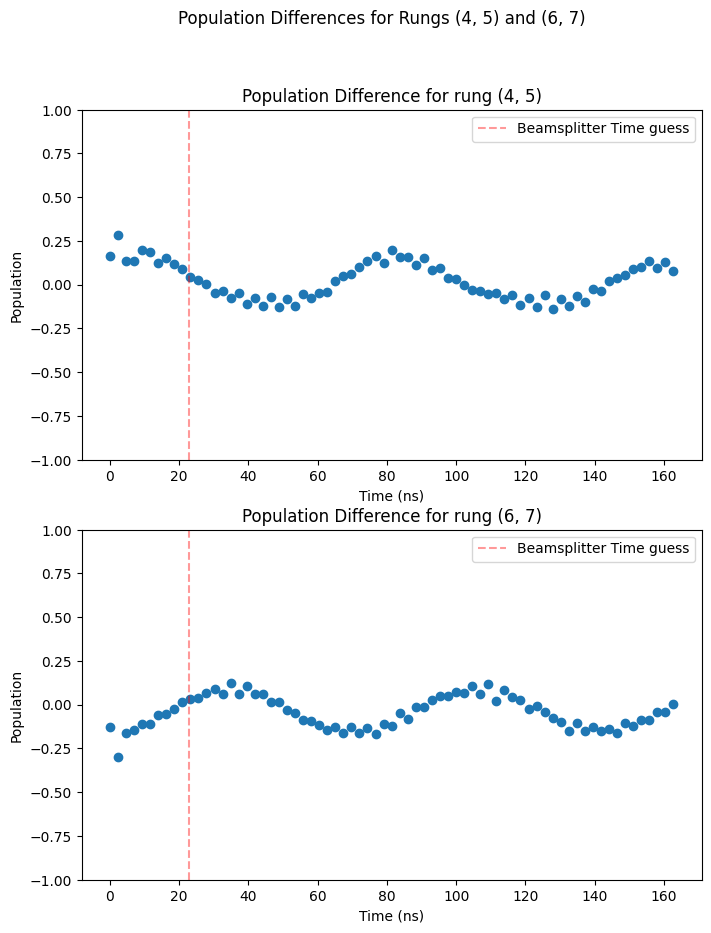

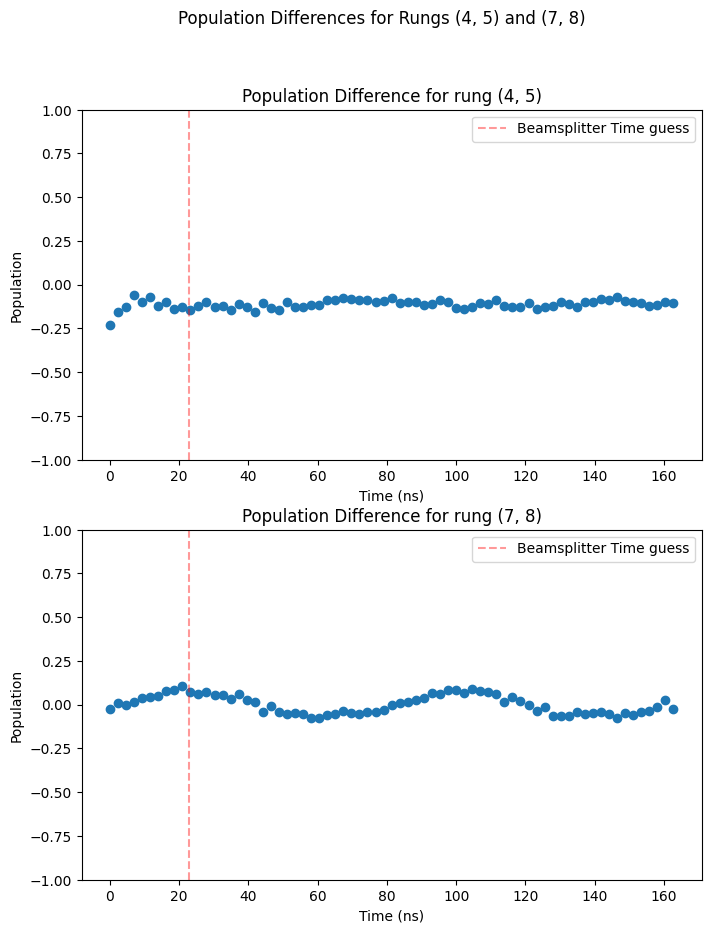

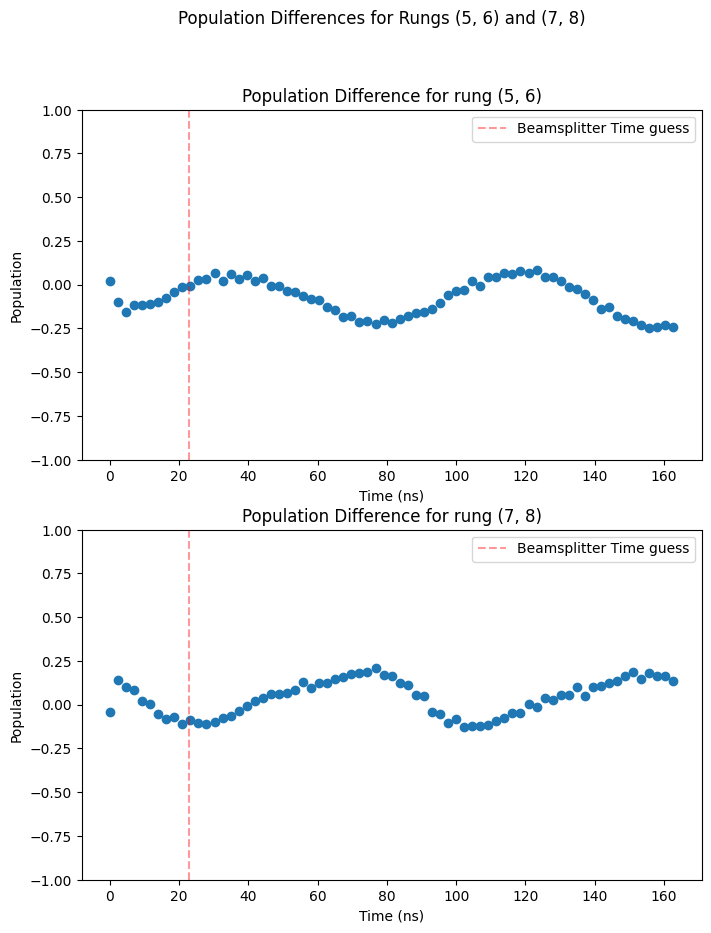

In [110]:
for correlation_pair in correlation_pairs:

    population_difference = correlation_pair_to_population_difference[correlation_pair]
    times = correlation_pair_to_population_times[correlation_pair]

    # create two plots stacked vertically
    fig, axs = plt.subplots(2, 1, figsize=(8, 10))

    axs = axs.flatten()
    for i in range(len(axs)):


        axs[i].plot(times, population_difference[i,:], linestyle='', marker='o')

        axs[i].axvline(beamsplitter_time_guess, color='r', alpha=0.4, linestyle='--', label='Beamsplitter Time guess')
    
        axs[i].set_xlabel('Time (ns)')
        axs[i].set_ylabel('Population')
        axs[i].set_title(f'Population Difference for rung {correlation_pair[i]}')
        axs[i].legend()

        axs[i].set_ylim(-1, 1)

    plt.suptitle(f'Population Differences for Rungs {correlation_pair[0]} and {correlation_pair[1]}')

    plt.show()

# 2. Fit Beamsplitters

In [111]:
def cos_fit(t, A, omega, phi, offset):
    return A * np.cos(omega * t + phi) + offset

In [112]:
correlation_pair_to_beamsplitter_dict = {}

correlation_pair_to_beamsplitter_dict = {correlation_pair: {} for correlation_pair in correlation_pairs}

Using negative amp initial guess
amp: -0.1
frequency: 70.25
phase: 0.99
offset: 0.09


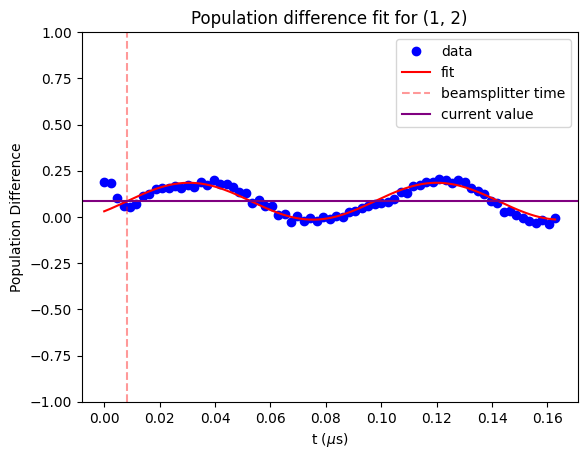

Fitted beamsplitter time for rung (1, 2): 8.25 ns ± 1.43 ns
Using negative amp initial guess
amp: 0.03
frequency: 93.14
phase: -2.41
offset: 0.04


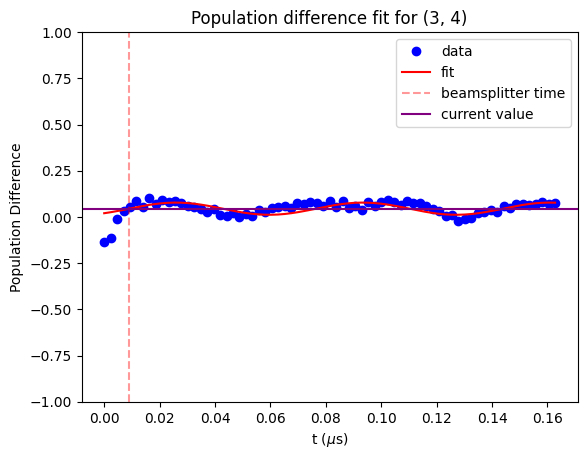

Fitted beamsplitter time for rung (3, 4): 9.02 ns ± 2.38 ns
Using negative amp initial guess
amp: -0.14
frequency: 87.82
phase: -0.42
offset: 0.08


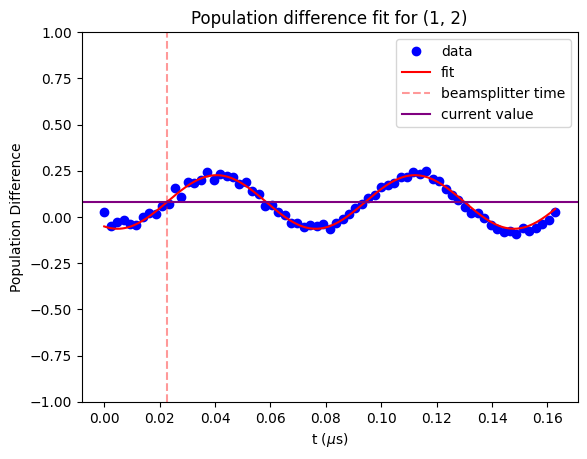

Fitted beamsplitter time for rung (1, 2): 22.69 ns ± 0.47 ns
Using negative amp initial guess
amp: 0.08
frequency: 79.19
phase: -1.03
offset: 0.09


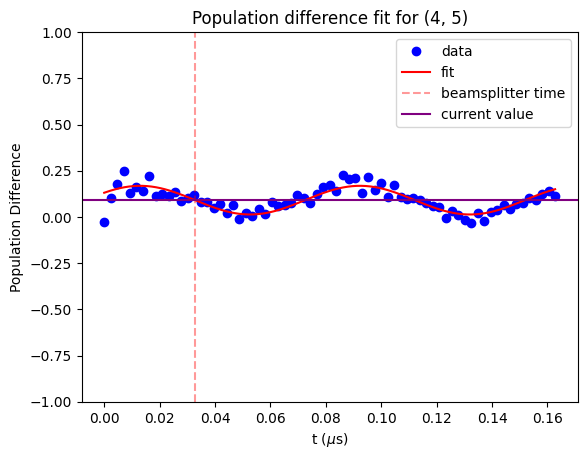

Fitted beamsplitter time for rung (4, 5): 32.82 ns ± 1.48 ns
Using negative amp initial guess
amp: -0.1
frequency: 70.25
phase: 0.99
offset: 0.09


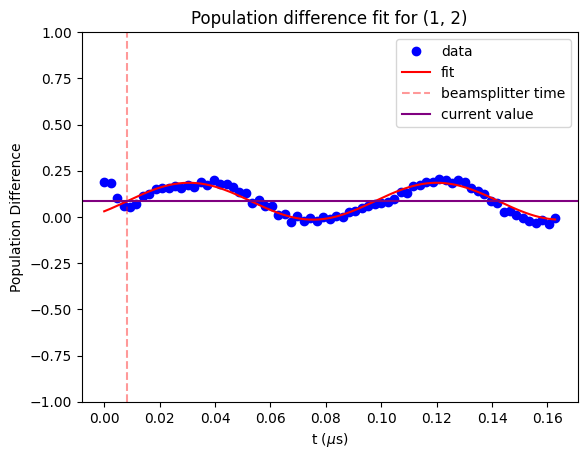

Fitted beamsplitter time for rung (1, 2): 8.25 ns ± 1.43 ns
Using negative amp initial guess
amp: -0.13
frequency: 75.29
phase: 0.54
offset: -0.07


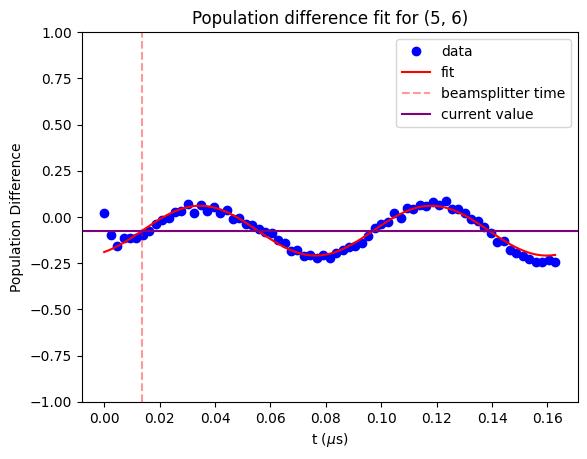

Fitted beamsplitter time for rung (5, 6): 13.70 ns ± 0.98 ns
Using negative amp initial guess
amp: -0.14
frequency: 87.82
phase: -0.42
offset: 0.08


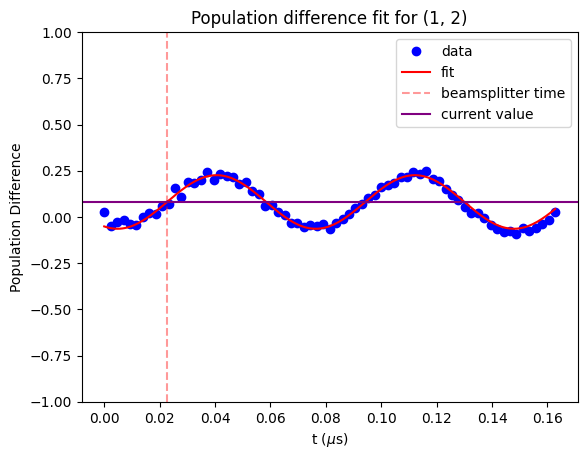

Fitted beamsplitter time for rung (1, 2): 22.69 ns ± 0.47 ns
Using negative amp initial guess
amp: -0.02
frequency: 55.02
phase: 2.57
offset: -0.04


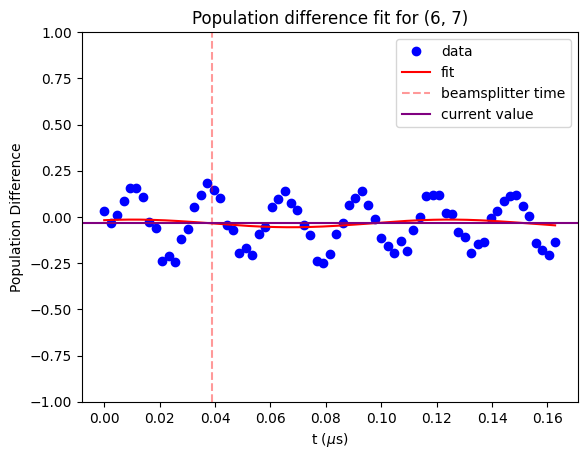

Fitted beamsplitter time for rung (6, 7): 38.95 ns ± 47.08 ns
amp: -0.1
frequency: 70.25
phase: 0.99
offset: 0.09


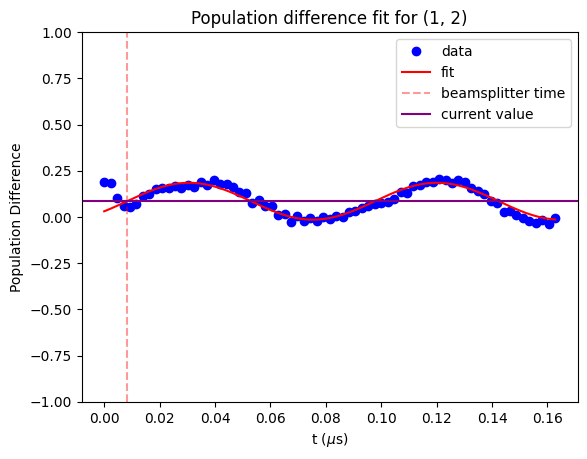

Fitted beamsplitter time for rung (1, 2): 8.25 ns ± 1.43 ns
amp: 0.13
frequency: 75.64
phase: 1.13
offset: 0.04


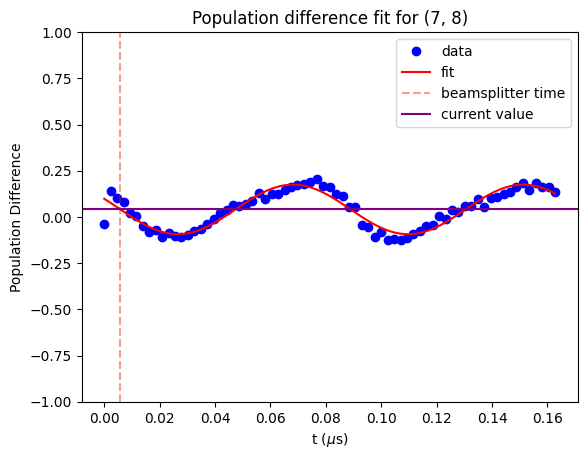

Fitted beamsplitter time for rung (7, 8): 5.85 ns ± 1.04 ns
Using negative amp initial guess
amp: -0.21
frequency: 90.75
phase: -0.5
offset: -0.04


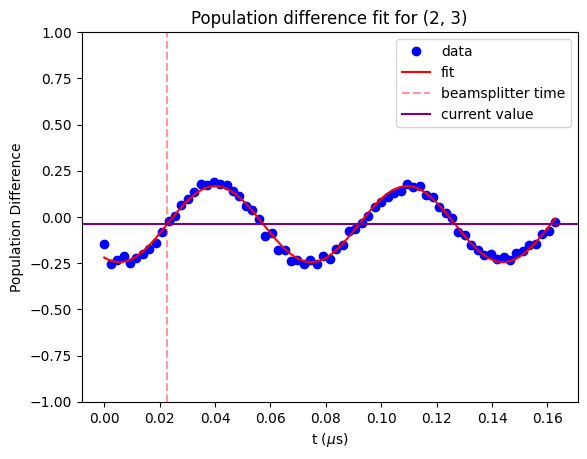

Fitted beamsplitter time for rung (2, 3): 22.77 ns ± 0.31 ns
amp: 0.14
frequency: 79.98
phase: -0.5
offset: 0.02


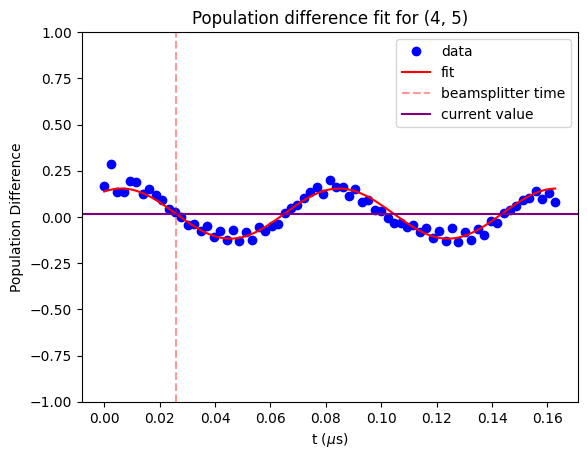

Fitted beamsplitter time for rung (4, 5): 25.83 ns ± 0.90 ns
Using negative amp initial guess
amp: -0.2
frequency: 89.26
phase: -0.48
offset: -0.04


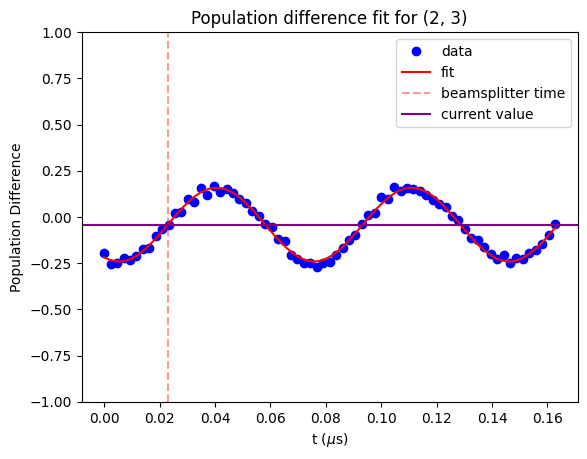

Fitted beamsplitter time for rung (2, 3): 22.94 ns ± 0.27 ns
Using negative amp initial guess
amp: -0.07
frequency: 70.84
phase: 0.25
offset: 0.01


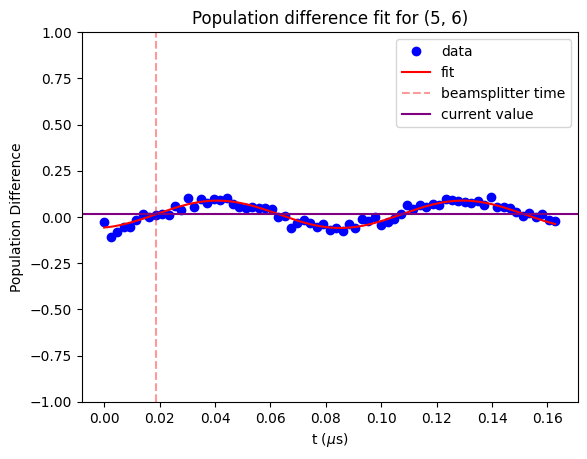

Fitted beamsplitter time for rung (5, 6): 18.62 ns ± 1.07 ns
Using negative amp initial guess
amp: -0.21
frequency: 90.75
phase: -0.5
offset: -0.04


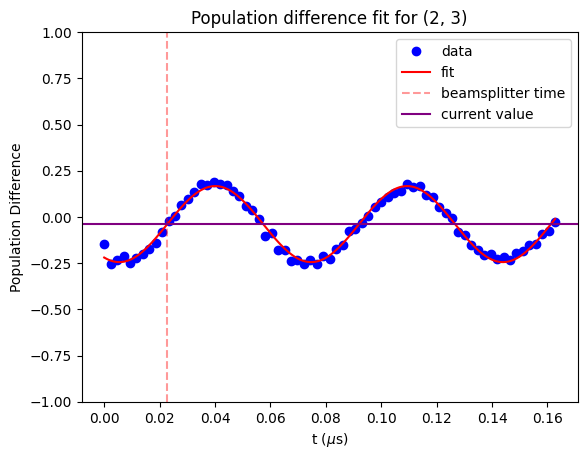

Fitted beamsplitter time for rung (2, 3): 22.77 ns ± 0.31 ns
Using negative amp initial guess
amp: -0.13
frequency: 88.64
phase: 0.03
offset: -0.04


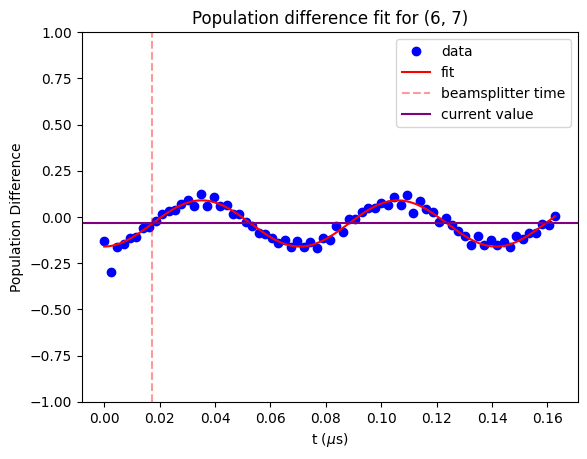

Fitted beamsplitter time for rung (6, 7): 17.42 ns ± 0.67 ns
Using negative amp initial guess
amp: -0.16
frequency: 89.82
phase: -0.39
offset: 0.01


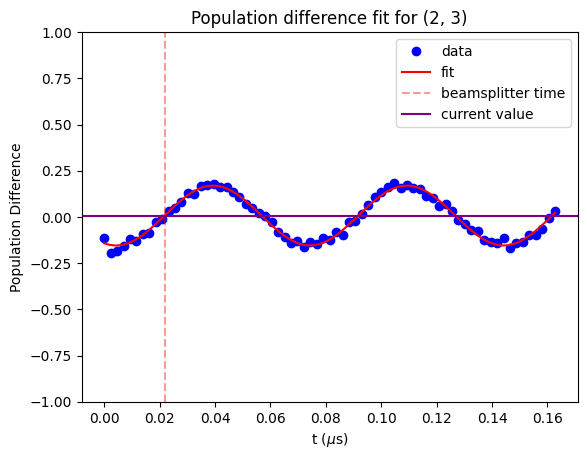

Fitted beamsplitter time for rung (2, 3): 21.79 ns ± 0.32 ns
Using negative amp initial guess
amp: -0.13
frequency: 84.4
phase: -1.2
offset: 0.02


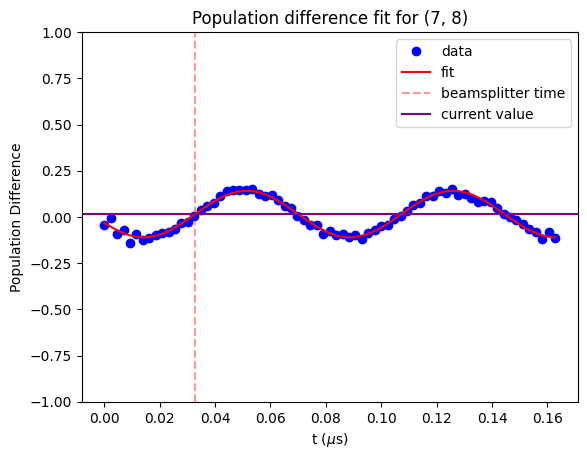

Fitted beamsplitter time for rung (7, 8): 32.83 ns ± 0.32 ns
Using negative amp initial guess
amp: 0.03
frequency: 93.14
phase: -2.41
offset: 0.04


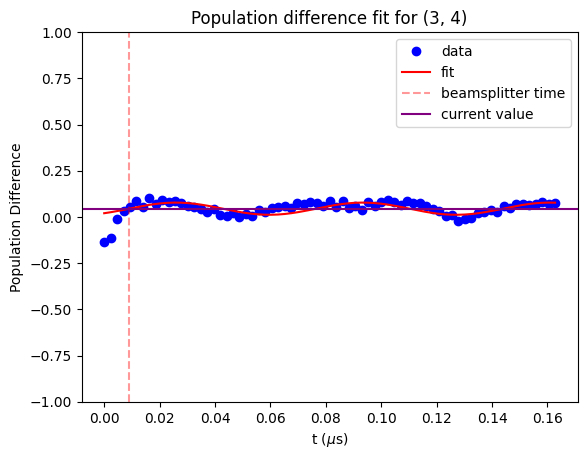

Fitted beamsplitter time for rung (3, 4): 9.02 ns ± 2.38 ns
Using negative amp initial guess
amp: -0.13
frequency: 75.29
phase: 0.54
offset: -0.07


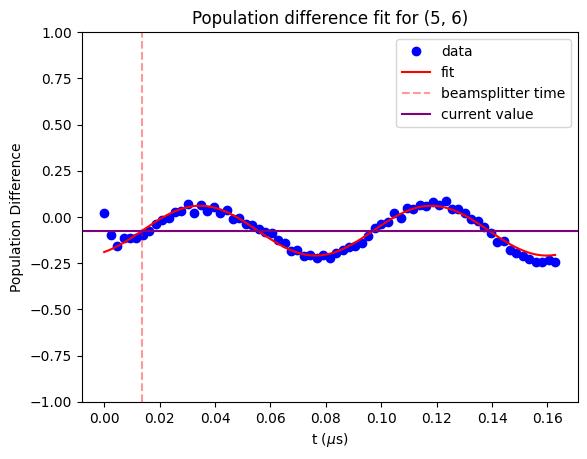

Fitted beamsplitter time for rung (5, 6): 13.70 ns ± 0.98 ns
Using negative amp initial guess
amp: 0.03
frequency: 87.72
phase: -2.04
offset: 0.02


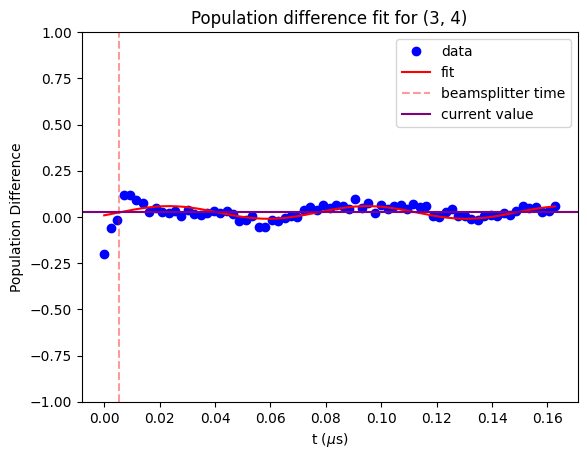

Fitted beamsplitter time for rung (3, 4): 5.36 ns ± 2.73 ns
Using negative amp initial guess
amp: -0.13
frequency: 82.62
phase: 0.47
offset: -0.11


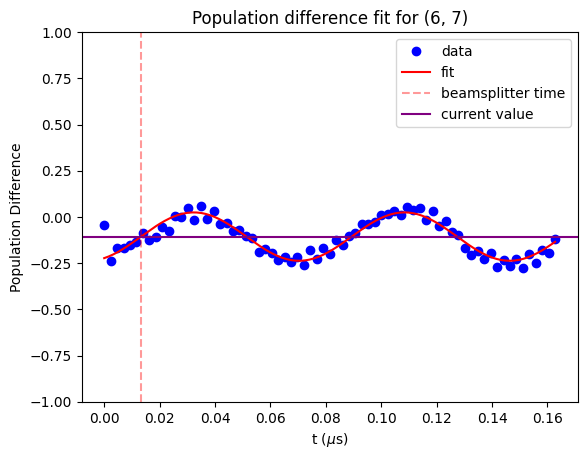

Fitted beamsplitter time for rung (6, 7): 13.29 ns ± 0.92 ns
amp: 0.03
frequency: 93.15
phase: -2.41
offset: 0.04


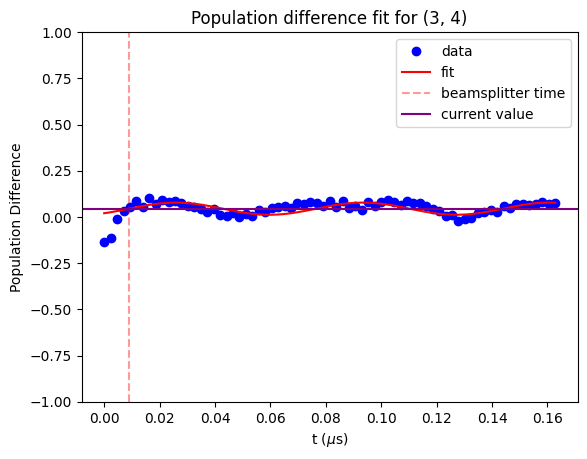

Fitted beamsplitter time for rung (3, 4): 9.02 ns ± 2.38 ns
amp: 0.13
frequency: 75.64
phase: 1.13
offset: 0.04


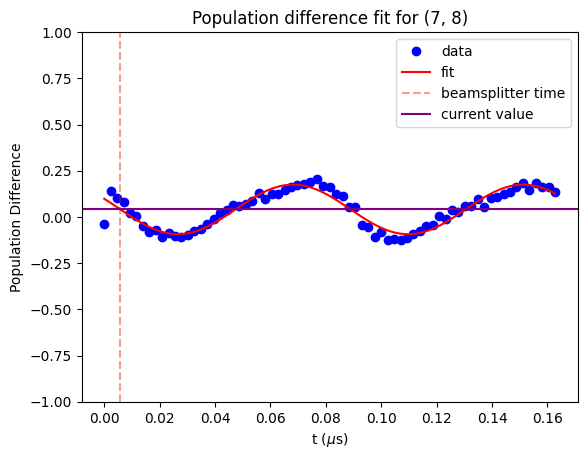

Fitted beamsplitter time for rung (7, 8): 5.85 ns ± 1.04 ns
amp: 0.14
frequency: 79.98
phase: -0.5
offset: 0.02


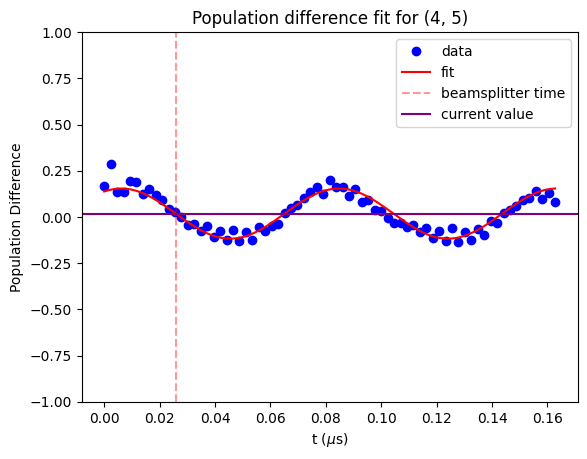

Fitted beamsplitter time for rung (4, 5): 25.83 ns ± 0.90 ns
amp: -0.13
frequency: 88.64
phase: 0.03
offset: -0.04


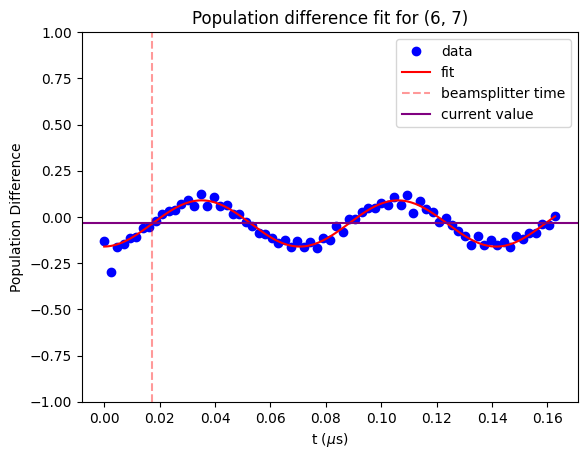

Fitted beamsplitter time for rung (6, 7): 17.42 ns ± 0.67 ns
amp: 0.01
frequency: 97.03
phase: -1.35
offset: -0.11


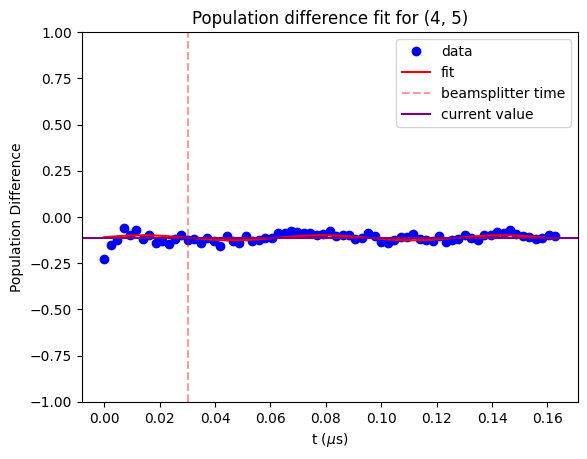

Fitted beamsplitter time for rung (4, 5): 30.12 ns ± 4.47 ns
Using negative amp initial guess
amp: -0.07
frequency: 79.9
phase: 1.3
offset: 0.0


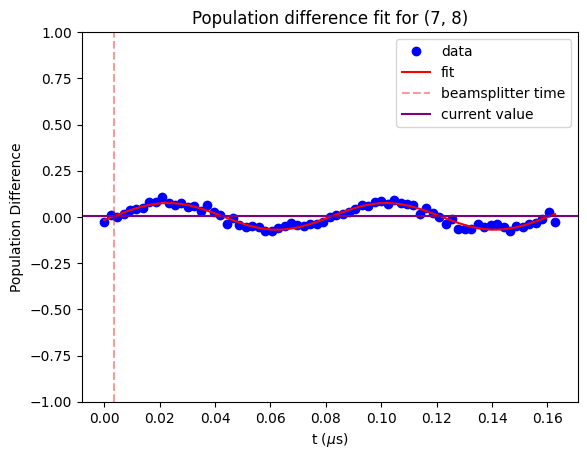

Fitted beamsplitter time for rung (7, 8): 3.41 ns ± 0.82 ns
Using negative amp initial guess
amp: -0.13
frequency: 75.29
phase: 0.54
offset: -0.07


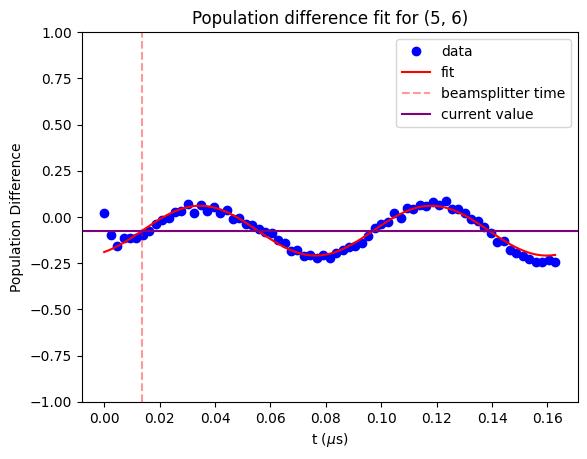

Fitted beamsplitter time for rung (5, 6): 13.70 ns ± 0.98 ns
Using negative amp initial guess
amp: 0.09
frequency: 57.03
phase: -3.14
offset: 0.04


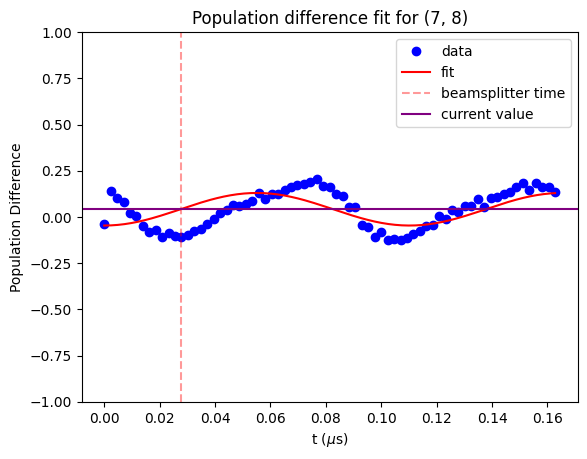

Fitted beamsplitter time for rung (7, 8): 27.54 ns ± 2.86 ns


In [113]:
for correlation_pair in correlation_pairs:

    population_difference = correlation_pair_to_population_difference[correlation_pair]
    times = correlation_pair_to_population_times[correlation_pair]

    times_mus = times * 1e-3  # convert to microseconds

    start_cutoff = 0


    # iterate over two pairs in each correlation_pair
    for i in range(population_difference.shape[0]):

        coupling_MHz = abs(coupling_point_config['coupling'][f'J_{correlation_pair[i][0]}{correlation_pair[i][1]}'])

        offset_guess = np.mean(population_difference)
        amplitude_guess = (np.max(population_difference) - np.min(population_difference)) / 2
        frequency_guess = 2 * coupling_MHz * 2 * np.pi

        initial_guess = [amplitude_guess, frequency_guess, 0, offset_guess]

        # compare mean squared error for original vs phase-shifted (pi) initial guesses
        pred_orig = cos_fit(times_mus, *initial_guess)
        mse_orig = np.mean((population_difference - pred_orig)**2)

        initial_guess_neg = initial_guess.copy()
        initial_guess_neg[0] *= -1
        pred_pi = cos_fit(times_mus, *initial_guess_neg)
        mse_pi = np.mean((population_difference - pred_pi)**2)

        if mse_pi < mse_orig:
            initial_guess = initial_guess_neg
            print('Using negative amp initial guess')


        bounds = ((-2*amplitude_guess, 0, -np.pi, -1), (2*amplitude_guess, 4*frequency_guess, np.pi, 1))

        # fit

        popt, pcov = curve_fit(cos_fit, times_mus[start_cutoff:], population_difference[i][start_cutoff:], p0=initial_guess, bounds=bounds)
        
        amp, frequency, phase, offset = popt
        perr = np.sqrt(np.diag(pcov))

        beamsplitter_time = (np.pi/2 - phase)/frequency
        while beamsplitter_time < 0:
            beamsplitter_time += np.pi/frequency

        while beamsplitter_time > np.pi/frequency:
            beamsplitter_time -= np.pi/frequency

        # error propogation

        # Extract individual parameter errors
        frequency_err = perr[1]  # frequency is index 1
        phase_err = perr[2]      # phase is index 2

        # Get covariance between frequency and phase
        freq_phase_covariance = pcov[1, 2]


        # Error propagation for t_BS = f(phase, frequency) = (π/2 - phase)/frequency
        df_dphase = -1/frequency
        df_dfrequency = -(np.pi/2 - phase)/(frequency**2)


        # Error propagation formula, unchanged by while loops
        beamsplitter_time_err = np.sqrt(
            (df_dphase**2) * (phase_err**2) +
            (df_dfrequency**2) * (frequency_err**2) +
            2 * df_dphase * df_dfrequency * freq_phase_covariance
        )

        print(f'amp: {round(amp,2)}')
        print(f'frequency: {round(frequency,2)}')
        print(f'phase: {round(phase,2)}')
        print(f'offset: {round(offset,2)}')


        fit_times = np.linspace(times_mus[0], times_mus[-1], 201)

        plt.plot(times_mus, population_difference[i], linestyle='', color='blue', marker='o', label='data')
        # plt.plot(fit_times, cos_fit(fit_times, *initial_guess), label='initial guess')
        plt.plot(fit_times, cos_fit(fit_times, *popt), color='red', label='fit')

        plt.axvline(x=beamsplitter_time, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)

        plt.axhline(y=offset, color='purple', label='current value')

        plt.xlabel('t ($\mu$s)')
        plt.ylabel('Population Difference')


        plt.title(f'Population difference fit for {correlation_pair[i]}')

        plt.ylim(-1,1)

        plt.legend()
        plt.show()

        print(f'Fitted beamsplitter time for rung {correlation_pair[i]}: {beamsplitter_time*1e3:.2f} ns ± {beamsplitter_time_err*1e3:.2f} ns')
    
  
        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_{i+1}'] = beamsplitter_time * 1e3 # ns
        correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_{i+1}_error'] = beamsplitter_time_err * 1e3 # ns

    beamsplitter_time_1 = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1']
    beamsplitter_time_2 = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2']

    beamsplitter_time_1_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_1_error']
    beamsplitter_time_2_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_2_error']

    beamsplitter_time_average = (beamsplitter_time_1 + beamsplitter_time_2)/2
    beamsplitter_time_average_error = np.sqrt(beamsplitter_time_1_error**2 + beamsplitter_time_2_error**2) / 2

    correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average'] = beamsplitter_time_average
    correlation_pair_to_beamsplitter_dict[correlation_pair][f'beamsplitter_time_average_error'] = beamsplitter_time_average_error



# 3. Calculate Current Correlation

In [77]:
def get_interpolation_value(times, current_correlation, beamsplitter_time, beamsplitter_error, plot_interpolation=False):

    interpolation_func = interp1d(times, current_correlation, kind='linear', fill_value="extrapolate")
    
    current_correlation_value = interpolation_func(beamsplitter_time)
    
    # Calculate derivative using interpolation at nearby points
    dt_small = 0.1  # small time step for derivative calculation
    if beamsplitter_time + dt_small <= times[-1] and beamsplitter_time - dt_small >= times[0]:
        derivative = (interpolation_func(beamsplitter_time + dt_small) - 
                    interpolation_func(beamsplitter_time - dt_small)) / (2 * dt_small)
    else:
        # Fall back to numerical derivative at nearest index
        beamsplitter_index = np.argmin(np.abs(times - beamsplitter_time))
        dt = times[1] - times[0]
        if beamsplitter_index > 0 and beamsplitter_index < len(current_correlation) - 1:
            derivative = (current_correlation[beamsplitter_index + 1] - current_correlation[beamsplitter_index - 1]) / (2 * dt)
        else:
            derivative = 0  # or handle edge case differently

    # Error propagation
    beamsplitter_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']
    current_correlation_error = abs(derivative) * beamsplitter_error


    if plot_interpolation:
        fit_times = np.linspace(times[0], times[-1], 501)
        plt.plot(times, current_correlation, linestyle='', marker='o', label='data')
        plt.plot(fit_times, interpolation_func(fit_times), label='interpolation')
        
        plt.legend()

        plt.xlabel('Time (ns)')
        plt.ylabel('Current Correlation')

        plt.ylim(-10, 10)
        
        plt.show()

    return current_correlation_value, current_correlation_error


In [79]:
correlation_pair_to_current_correlation_value = {}
correlation_pair_to_current_correlation_error = {}

beamsplitter_average: 22.54 ns


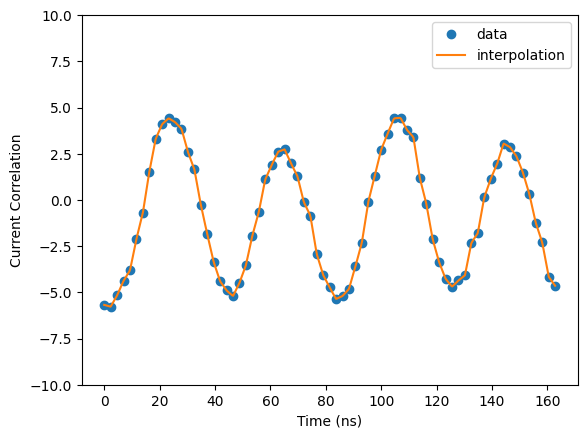

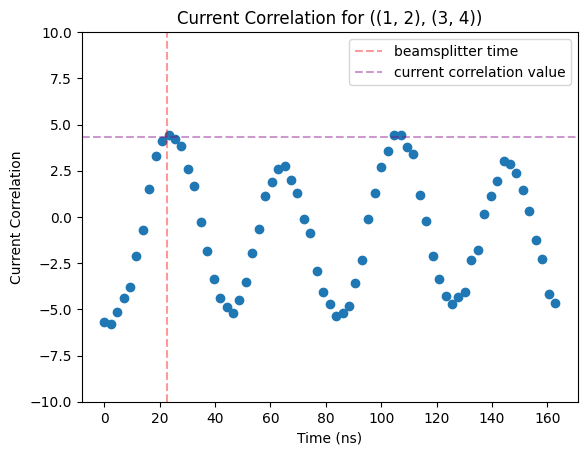

beamsplitter_average: 20.38 ns


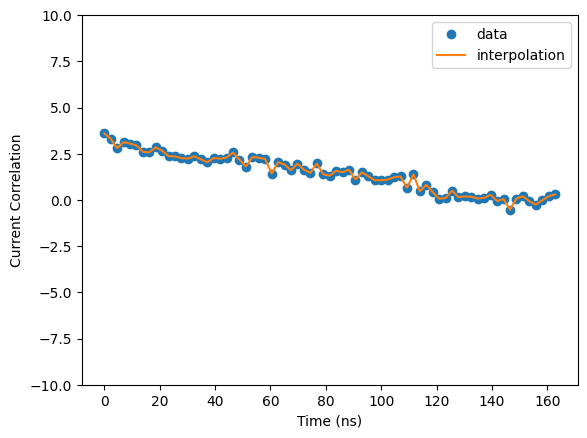

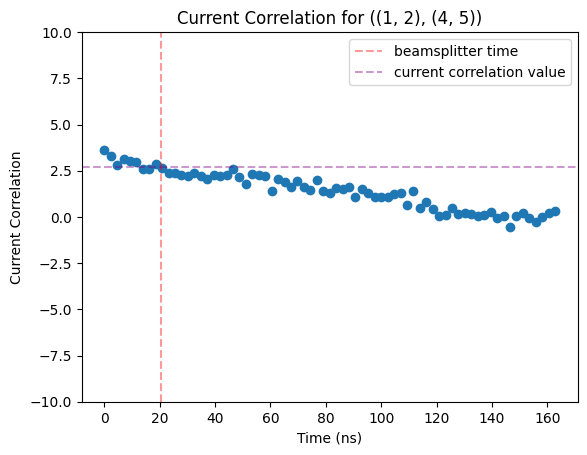

beamsplitter_average: 25.6 ns


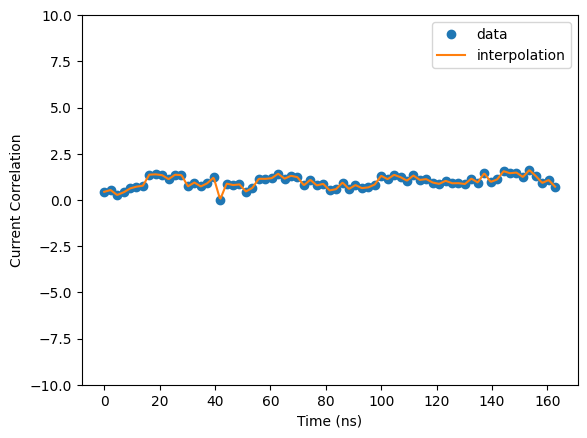

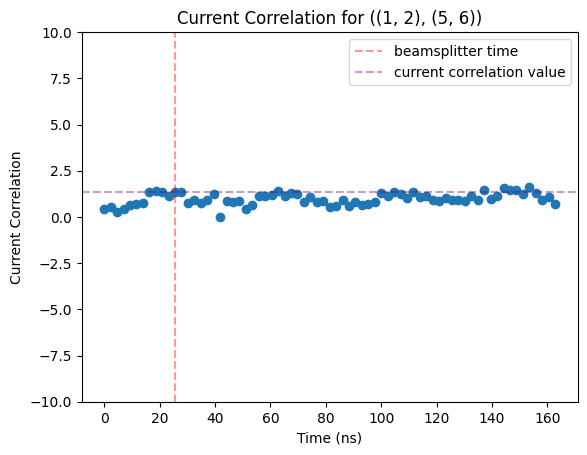

beamsplitter_average: 18.06 ns


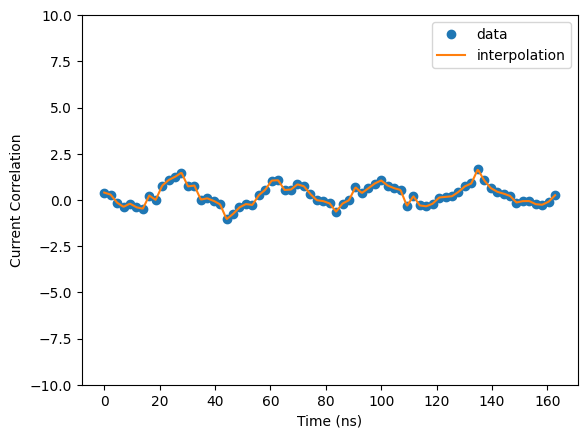

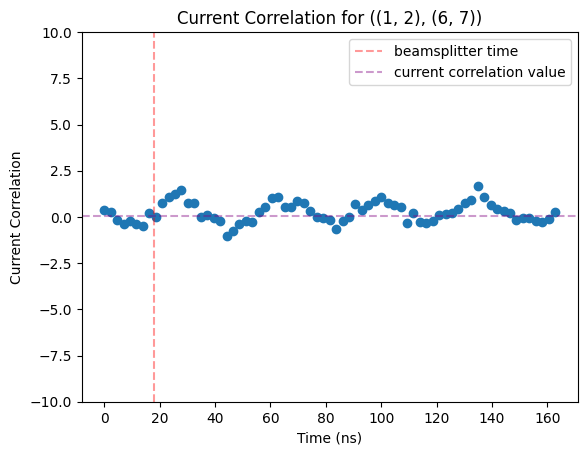

beamsplitter_average: 20.54 ns


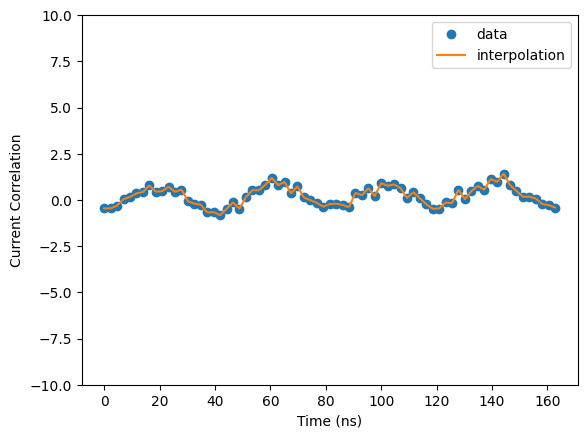

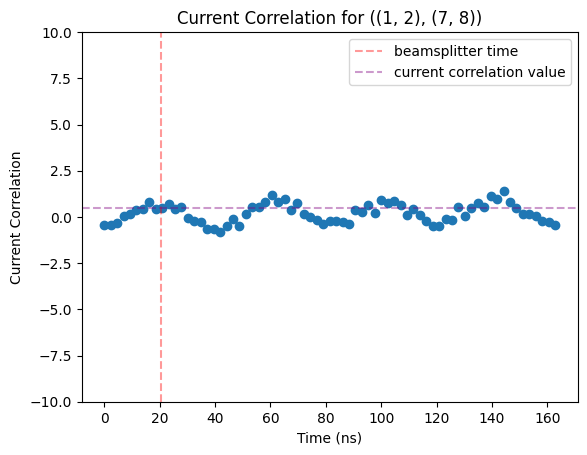

beamsplitter_average: 23.39 ns


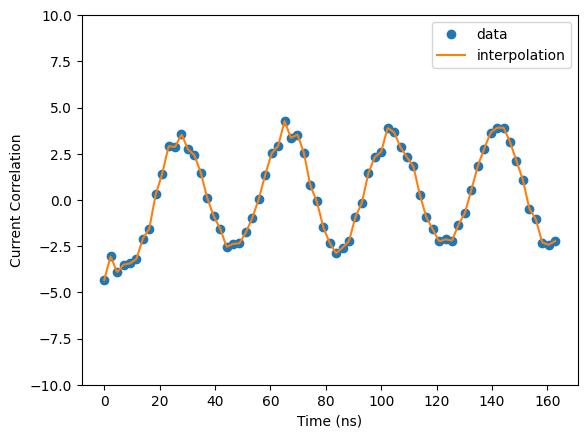

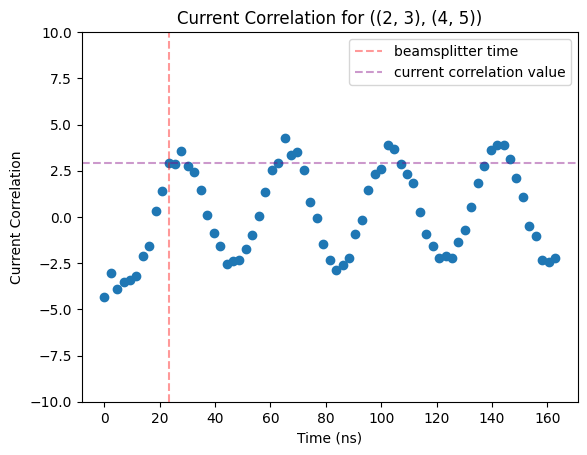

beamsplitter_average: 15.14 ns


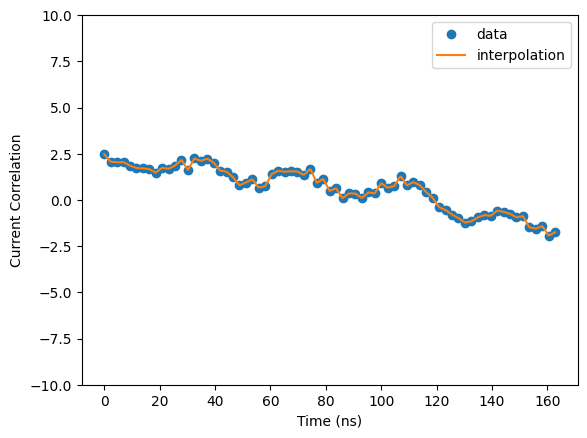

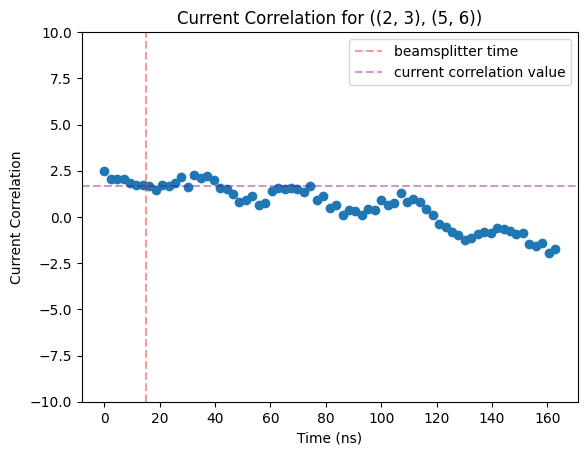

beamsplitter_average: 25.68 ns


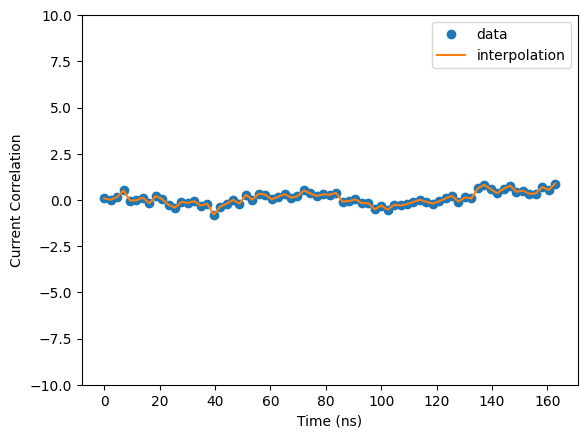

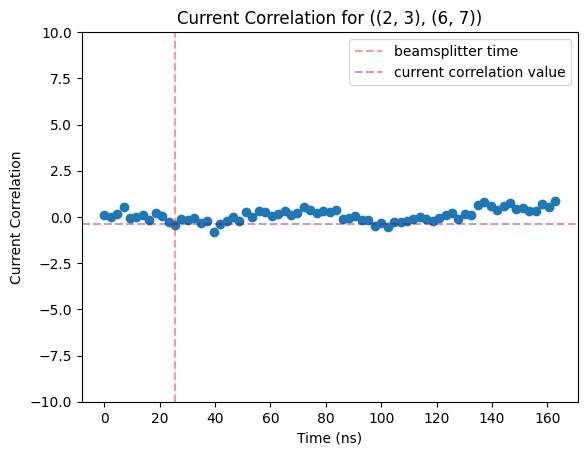

beamsplitter_average: 16.6 ns


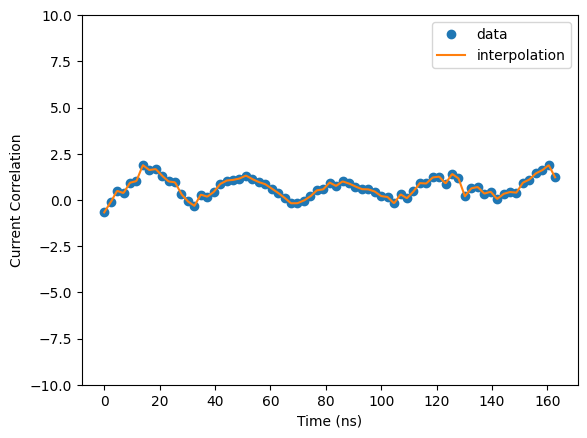

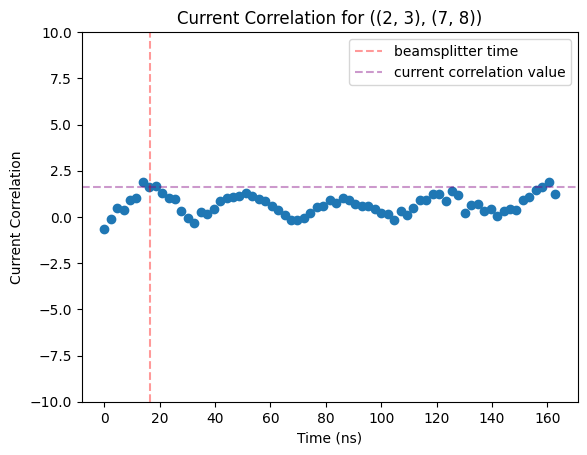

beamsplitter_average: 22.66 ns


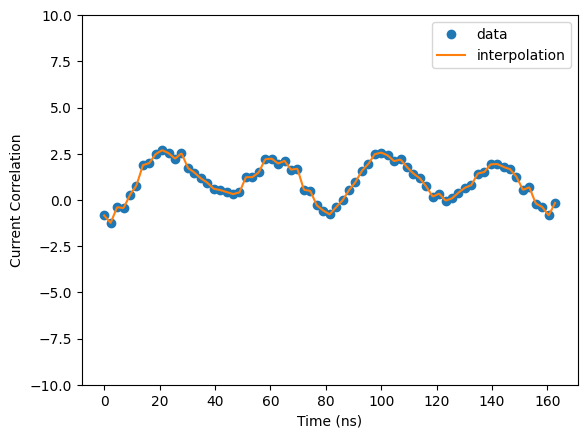

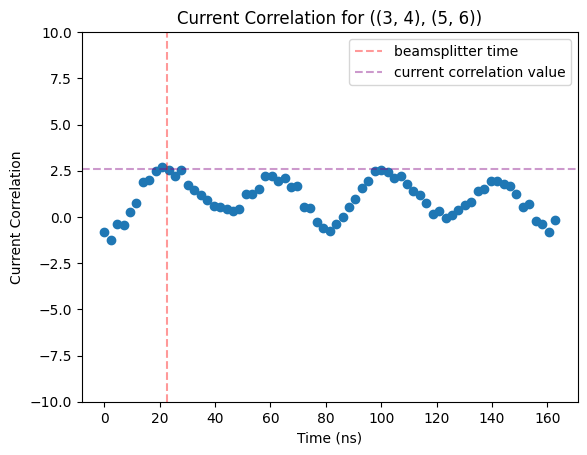

beamsplitter_average: 17.91 ns


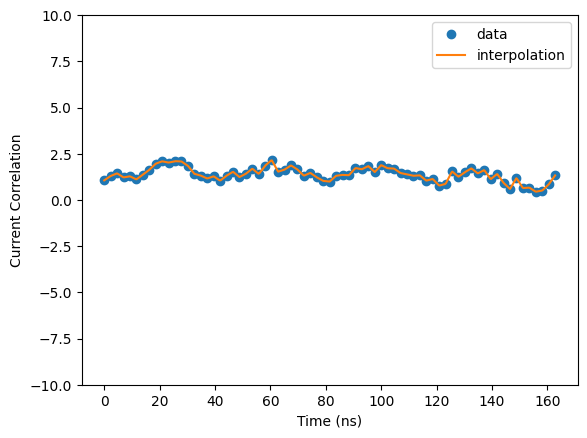

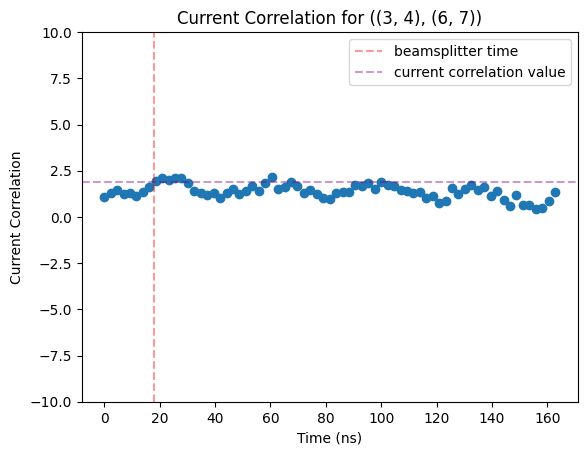

beamsplitter_average: 17.6 ns


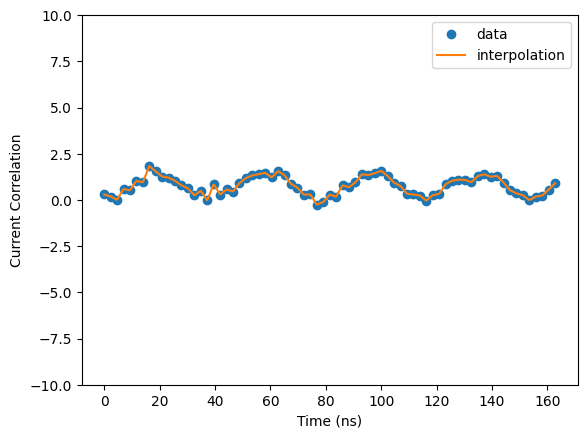

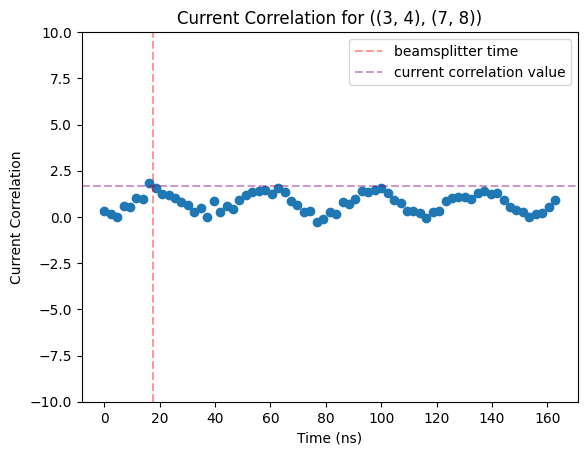

beamsplitter_average: 22.37 ns


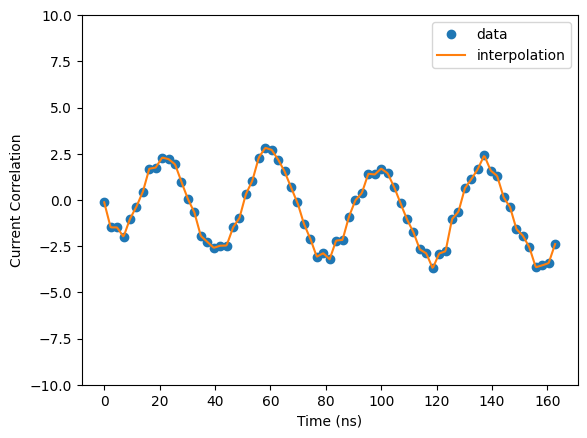

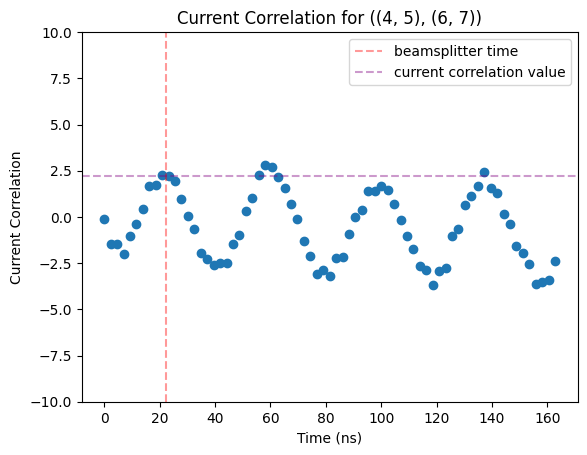

beamsplitter_average: 17.93 ns


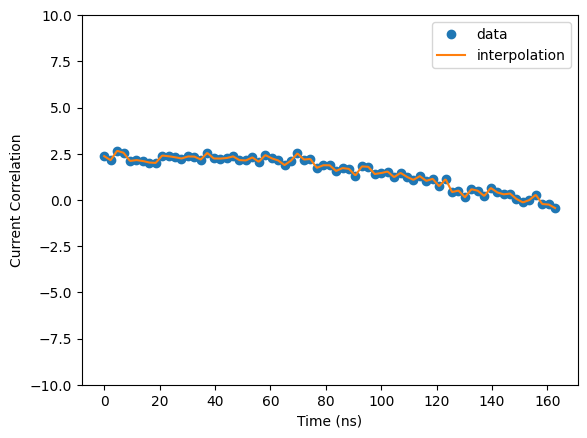

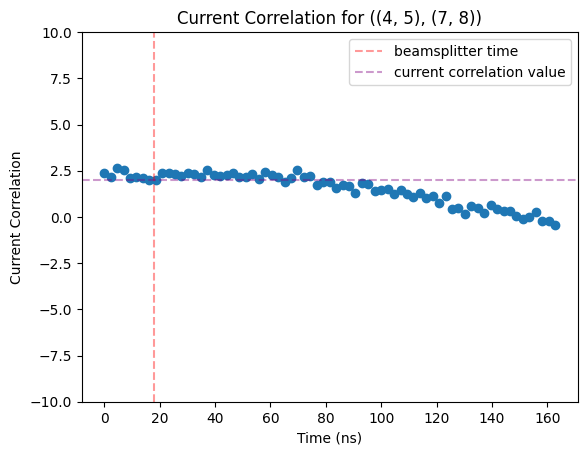

beamsplitter_average: 20.66 ns


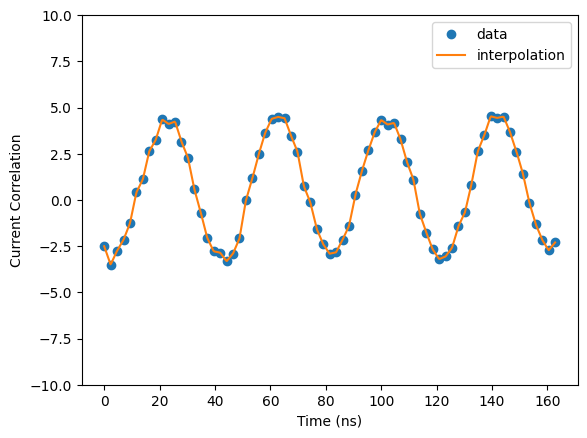

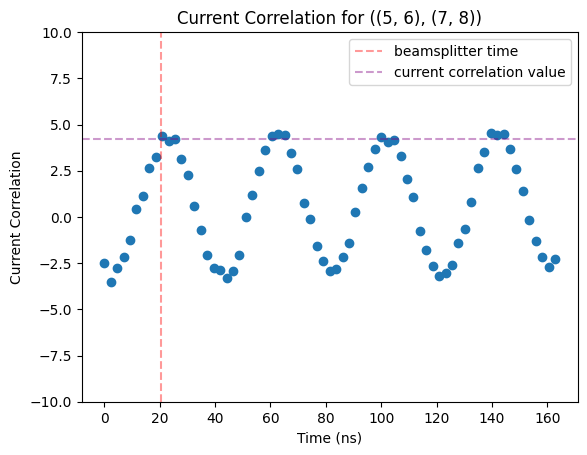

In [80]:
for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]
    current_correlation = correlation_pair_data['current_correlation']
    times = correlation_pair_data['times']

    beamsplitter_average = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average']

    print(f'beamsplitter_average: {round(beamsplitter_average, 2)} ns')

    # value
    beamsplitter_index = np.argmin(np.abs(times - beamsplitter_average))

    current_correlation_value = current_correlation[beamsplitter_index]


    # error
    beamsplitter_average_error = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']

    current_correlation_value, current_correlation_error = get_interpolation_value(times, current_correlation, beamsplitter_average, beamsplitter_average_error, plot_interpolation=True)

    correlation_pair_to_current_correlation_value[correlation_pair] = current_correlation_value
    correlation_pair_to_current_correlation_error[correlation_pair] = current_correlation_error

    plt.plot(times, current_correlation, linestyle='', marker='o')
    
    plt.axvline(x=beamsplitter_average, color='red', linestyle='--', label='beamsplitter time', alpha=0.4)
    plt.axhline(y=current_correlation_value, color='purple', linestyle='--', label='current correlation value', alpha=0.4)
    
    plt.xlabel('Time (ns)')
    plt.ylabel('Current Correlation')


    plt.ylim(-10, 10)

    plt.title(f'Current Correlation for {correlation_pair}')
    plt.legend()
    plt.show()

### 3.2 Plot vs Distance

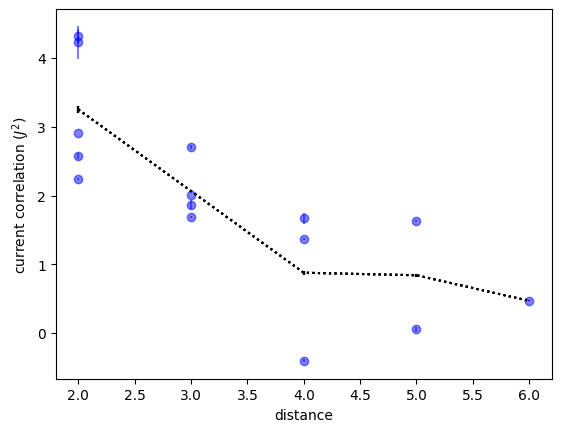

In [84]:
# plot current correlations values by distance

distances = list(range(2,7))
distance_to_correlation_value_list = {i: [] for i in distances}
distance_to_correlation_error_list = {i: [] for i in distances}

for correlation_pair in correlation_pairs:
    current_correlation_value = correlation_pair_to_current_correlation_value[correlation_pair]
    current_correlation_error = correlation_pair_to_current_correlation_error[correlation_pair]

    distance = abs(correlation_pair[0][0] - correlation_pair[1][0])

    distance_to_correlation_value_list[distance].append(current_correlation_value)
    distance_to_correlation_error_list[distance].append(current_correlation_error)


current_correlation_average_values = [np.mean(distance_to_correlation_value_list[distance]) for distance in distance_to_correlation_value_list]

current_correlation_average_errors = [np.sqrt(np.sum(np.array(distance_to_correlation_error_list[distance])**2)) / len(distance_to_correlation_error_list[distance]) for distance in distance_to_correlation_error_list]

current_correlation_total = sum(current_correlation_average_values)

current_correlation_total_error = np.sqrt(np.sum(np.array(current_correlation_average_errors)**2))

for distance in distances:
    values = distance_to_correlation_value_list[distance]

    plt.errorbar([distance]*len(values), values, yerr=distance_to_correlation_error_list[distance], marker='o', linestyle='', color='blue', alpha=0.5)

    plt.errorbar(distances, current_correlation_average_values, yerr=current_correlation_average_errors, linestyle=':', color='black', alpha=0.8)

plt.xlabel('distance')
plt.ylabel('current correlation ($J^2$)')

plt.show()


### 3.3 Save Data

In [95]:
data_dictionary = {}

for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point]['highest'][str(correlation_pair)]

    correlation_pair_data['current_correlation_value'] = float(correlation_pair_to_current_correlation_value[correlation_pair])
    correlation_pair_data['current_correlation_error'] = float(correlation_pair_to_current_correlation_error[correlation_pair])


    correlation_pair_data['beamsplitter_time'] = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average']
    correlation_pair_data['beamsplitter_time_error'] = correlation_pair_to_beamsplitter_dict[correlation_pair]['beamsplitter_time_average_error']

    data_dictionary[correlation_pair] = correlation_pair_data


data_dictionary['distances'] = distances
data_dictionary['current_correlation_averages'] = current_correlation_average_values
data_dictionary['current_correlation_average_errors'] = current_correlation_average_errors

data_dictionary['distance_to_current_correlation_value'] = distance_to_correlation_value_list
data_dictionary['distance_to_current_correlation_error'] = distance_to_correlation_error_list

data_dictionary['current_correlation_total'] = current_correlation_total
data_dictionary['current_correlation_total_error'] = current_correlation_total_error



In [94]:
print(data_dictionary.keys())

dict_keys([((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8)), 'distances', 'current_correlation_averages', 'current_correlation_average_errors', 'distance_to_current_correlation_value', 'distance_to_current_correlation_error', 'current_correlation_total', 'current_correlation_total_error'])


In [97]:
data_filename = 'current_correlations_data.h5'

eigenstate = 'highest'

keys = ('data', coupling_point, eigenstate)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)